In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\EDA projects\Heart_data_analysis\heart.csv")

<>:24: SyntaxWarning: invalid escape sequence '\E'
<>:24: SyntaxWarning: invalid escape sequence '\E'
C:\Users\awara\AppData\Local\Temp\ipykernel_32504\654263571.py:24: SyntaxWarning: invalid escape sequence '\E'
  df = pd.read_csv("D:\EDA projects\Heart_data_analysis\heart.csv")


# Prepare X and y

In [9]:
df_clean = df.drop_duplicates().copy()

In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (302, 13)
y shape: (302,)


##### After removing duplicate records, the dataset contains 302 unique observations and 13 input features.

In [11]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Data divided into:
- 80% training data
- 20% testing data

# Logistic Regression

In [14]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [15]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print(y_prob[:5])

[0.18539741 0.70776829 0.0071108  0.5637725  0.9130956 ]


# Decision Tree

In [16]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



# Random Forest

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



# Comparison Table

In [18]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Decision Tree,0.803279,0.818182,0.818182,0.818182
2,Random Forest,0.754098,0.764706,0.787879,0.776119


# Confusion Matrix

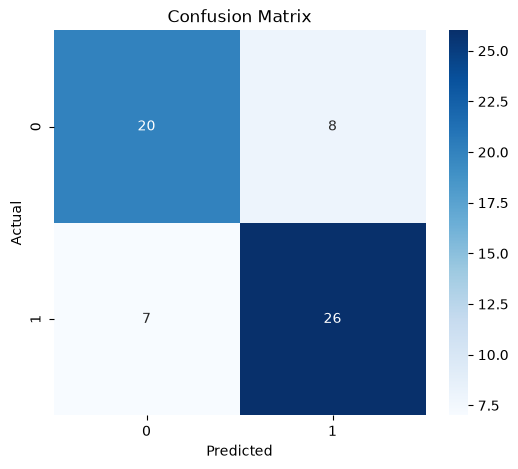

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

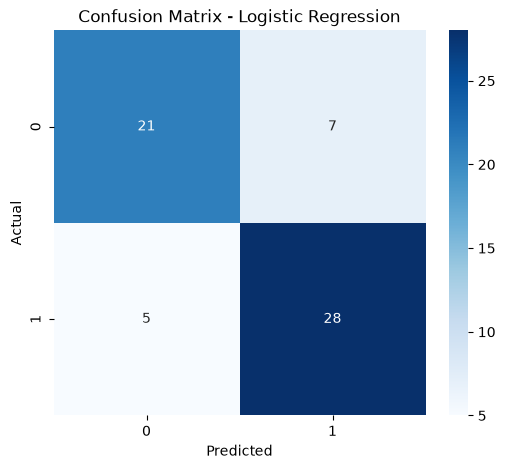

In [22]:
y_pred_final = logistic_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# ROC-AUC

In [23]:
y_probability = rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8701298701298701


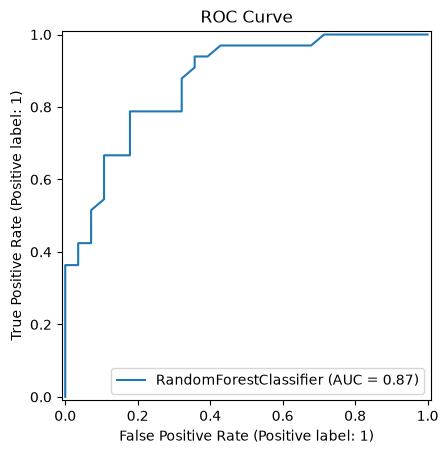

In [24]:
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

# Feature importance

In [25]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

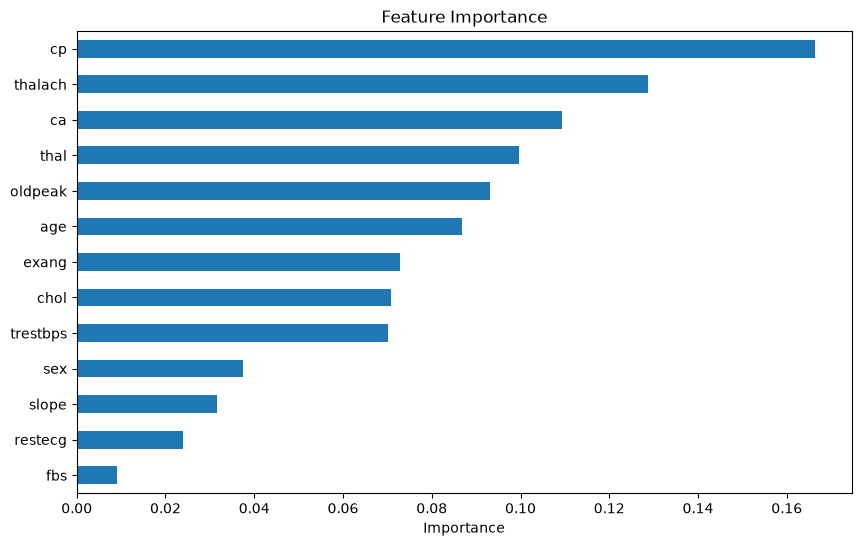

In [26]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

# Final Model Selection

In [27]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df.sort_values(
    by="CV F1 Mean",
    ascending=False
)

c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.843682,0.024867
2,Random Forest,0.839682,0.024814
1,Decision Tree,0.738324,0.034329


In [28]:
best_model_name = cv_df.loc[
    cv_df["CV F1 Mean"].idxmax(),
    "Model"
]

print("Final Model:", best_model_name)

Final Model: Logistic Regression


In [29]:
final_model = models[best_model_name]

final_model.fit(X_train, y_train)

c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

# Final Test Evaluation

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = final_model.predict(X_test)

print("Final Model:", best_model_name)
print()

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Final Model: Logistic Regression

Accuracy : 0.8032786885245902
Precision: 0.8
Recall   : 0.8484848484848485
F1 Score : 0.8235294117647058


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [32]:
y_prob = final_model.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

ROC-AUC: 0.8712121212121212


# Save the model

In [33]:
import joblib

joblib.dump(
    final_model,
    "../models/heart_disease_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [34]:
# Refit final model
final_model = logistic_model

final_model.fit(X_train, y_train)

# Test predict_proba
y_prob = final_model.predict_proba(X_test)[:, 1]

print(y_prob[:5])

[0.18539741 0.70776829 0.0071108  0.5637725  0.9130956 ]


c:\Users\awara\anaconda3\envs\heart-eda\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [35]:
import joblib

joblib.dump(
    final_model,
    "../models/heart_disease_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [36]:
import joblib

joblib.dump(
    logistic_model,
    "../models/heart_disease_model.pkl"
)

print("New model saved!")

New model saved!
